# **Phase 3A — AST Fine-Tuning with Cross-Entropy**

**Project:** RobustLungAI — Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers.

## Objective

Fine-tune the pretrained `MIT/ast-finetuned-audioset-10-10-0.4593` Audio Spectrogram Transformer (AST) for four-class respiratory sound classification using class-weighted cross-entropy.

## Dataset and inputs

* ICBHI 2017 Respiratory Sound Database.
* Phase 1 train, validation and test manifests.
* Raw audio recordings and respiratory-cycle annotations.
* Preprocessed, fixed-length waveform cache.

## Method

The notebook extracts annotated respiratory cycles, applies bandpass filtering and resampling, converts the waveforms using the pretrained AST feature extractor, and fine-tunes the four-class classifier.

## Evaluation

Model selection uses validation ICBHI score with early stopping. The selected checkpoint is evaluated on the validation set and the held-out test set.

## Reproducibility

This experiment uses the project's patient-level 70/15/15 split. Comparisons with other experiments or published studies require compatible data splits, preprocessing and evaluation protocols.

## Outputs

* Best validation-selected AST checkpoint.
* Training and validation curves.
* Validation and test metrics and confusion matrices.
* Experiment results exported to CSV.


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110 # Matplotlib figures render at 110 DPI.

## **1. Config**

Same reproducibility/config-first pattern as Phases 1-2. A few values differ deliberately from Phase 2's CNN config -- called out where that matters.

In [2]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# =========================
# Paths
# =========================

# Raw ICBHI dataset -- adjust to match your actual mounted path
ICBHI_DIR = Path(
   "/kaggle/input/datasets/husninm/icbhi-2017-challenge/ICBHI_final_database"
)


# Phase 1 notebook output -- for splits/train.csv, val.csv, test.csv
PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

# Raw-waveform cache for THIS notebook 
WAVEFORM_CACHE_DIR = Path("/kaggle/working/waveform_cache")
WAVEFORM_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = Path("/kaggle/working/results_phase3.csv")


# =========================
# Labels 
# =========================
LABELS = ["normal", "crackle", "wheeze", "both"]  


# =========================
# Audio preprocessing 
# =========================
TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0


# =========================
# AST model config
# =========================
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"


# =========================
# Training config
# =========================
BATCH_SIZE = 8          # AST is far larger (~86M params)
NUM_WORKERS = 2
LEARNING_RATE = 1e-5    # ~100x smaller than Phase 2's CNN LR -- fine-tuning a
                        
WEIGHT_DECAY = 0.01  # regularization.
WARMUP_RATIO = 0.1   # 10% of training steps are used for learning-rate warmup.
MAX_EPOCHS = 15          # AST converges quickly when fine-tuned (per HF's own
                         # guidance) -- expect far fewer epochs than the CNN needed
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0   # protects training from very large gradients.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

assert DEVICE.type == "cuda" # "Enable the GPU accelerator for this notebook before continuing.

Device: cuda


## **2. Load Phase 1 splits**

Reusing the same patient-level splits as Phase 2 -- same train/val/test cycles, just a different feature path from here on. Adjust column names below (`audio_path`, `start`, `end`, `label`) if your Phase 1 CSVs name them differently.

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing} -- check your Phase 1 CSV schema and adjust column names below."

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(4580, 14) (1133, 14) (1185, 14)


,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label,duration,spectrogram_path
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal,0.543,/kaggle/working/icbhi_processed/spectrograms/1...
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal,1.871,/kaggle/working/icbhi_processed/spectrograms/1...
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal,1.443,/kaggle/working/icbhi_processed/spectrograms/1...
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal,1.900,/kaggle/working/icbhi_processed/spectrograms/1...
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal,1.728,/kaggle/working/icbhi_processed/spectrograms/1...


## **3. Raw-Waveform Preprocessing**

The AST pipeline uses raw respiratory waveforms rather than the cached Log-Mel spectrograms used by the earlier baseline experiments.

Each annotated cycle is extracted from its original recording, bandpass-filtered, resampled to 16 kHz, and padded or truncated to eight seconds. The pretrained AST feature extractor subsequently converts the waveform into the model's expected input representation.

The preprocessing configuration must remain consistent with the waveform cache and trained checkpoint.


In [4]:
def bandpass_filter(signal, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=5):
    nyquist = sr / 2.0
    highcut = min(highcut, nyquist * 0.99)
    sos = butter(order, [lowcut, highcut], btype="band", fs=sr, output="sos")
    return sosfiltfilt(sos, signal).astype(np.float32)


def resample_audio(signal, orig_sr, target_sr=TARGET_SR):
    if orig_sr == target_sr:
        return signal
    return librosa.resample(signal, orig_sr=orig_sr, target_sr=target_sr).astype(np.float32)


def pad_or_truncate(signal, sr, target_duration=TARGET_DURATION):
    target_length = int(target_duration * sr)
    current_length = len(signal)

    if current_length == target_length:
        return signal
    if current_length > target_length:
        start = (current_length - target_length) // 2
        return signal[start : start + target_length]

    n_repeats = int(np.ceil(target_length / current_length))
    tiled = np.tile(signal, n_repeats)
    return tiled[:target_length]


def extract_cycle(audio, sr, start, end):
    start_idx = int(start * sr)
    end_idx = int(end * sr)
    return audio[start_idx:end_idx]


def preprocess_waveform(audio_path, start, end):
    audio, sr = librosa.load(audio_path, sr=None, mono=True)
    cycle = extract_cycle(audio, sr, start, end)
    cycle = bandpass_filter(cycle, sr)
    cycle = resample_audio(cycle, sr, TARGET_SR)
    cycle = pad_or_truncate(cycle, TARGET_SR, TARGET_DURATION)
    return cycle

## **4. Waveform Cache**

The waveform cache stores the extracted and preprocessed respiratory cycles as NumPy arrays. Later experiments can reuse these waveforms instead of repeating audio preprocessing.

**Cache policy:** Reuse existing files whenever available. During this documentation-cleanup pass, do not regenerate missing cache files. If a cache file is missing, report the missing path so the cache can be restored or rebuilt deliberately in a separate preprocessing step.

The cache directory must be configured to point to the intended existing cache location in the current environment.


In [5]:
def cache_waveforms(df, cache_dir=WAVEFORM_CACHE_DIR):
    paths = []
    for _, row in df.iterrows():
        cycle_id = f"{Path(row['audio_path']).stem}_{row['start']}_{row['end']}"
        out_path = cache_dir / f"{cycle_id}.npy"
        if not out_path.exists():
            waveform = preprocess_waveform(row["audio_path"], row["start"], row["end"])
            np.save(out_path, waveform)
        paths.append(str(out_path))
    return paths

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["waveform_path"] = cache_waveforms(df)
    print(f"{name}: cached {len(df)} waveforms")

# sanity check -- every cached waveform should be exactly TARGET_DURATION * TARGET_SR samples
sample_wave = np.load(train_df.iloc[0]["waveform_path"])
expected_len = int(TARGET_DURATION * TARGET_SR)
assert sample_wave.shape[0] == expected_len, f"Got {sample_wave.shape[0]}, expected {expected_len}"
print("Waveform shape check passed:", sample_wave.shape)

train: cached 4580 waveforms
val: cached 1133 waveforms
test: cached 1185 waveforms
Waveform shape check passed: (128000,)


## **5. AST Feature Extractor**

The pretrained AST feature extractor converts each preprocessed waveform into the input representation expected by the model. It handles spectrogram construction, padding or truncation and the checkpoint's configured normalization.

Do not apply an additional, independent normalization step unless the experiment configuration explicitly requires it.

A single cached waveform is used to verify the resulting tensor shape before dataset construction.


In [ ]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)
print(feature_extractor)

# Verify the AST feature extractor output on one cached waveform.
test_features = feature_extractor(sample_wave, sampling_rate=TARGET_SR, return_tensors="pt") # Take our waveform and convert it into the format AST expects.
print("input_values shape:", test_features["input_values"].shape)   # expect (1, 1024, 128)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

ASTFeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "ASTFeatureExtractor",
  "feature_size": 1,
  "max_length": 1024,
  "mean": -4.2677393,
  "num_mel_bins": 128,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": false,
  "sampling_rate": 16000,
  "std": 4.5689974
}

input_values shape: torch.Size([1, 1024, 128])


## **6. Dataset / DataLoader**

In [7]:
class ASTLungSoundDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS):
        self.df = df.reset_index(drop=True) # Reset the DataFrame index
        self.fe = feature_extractor # Store the feature extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)} # Convert labels to numbers

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])

        features = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt") # waveform to ASTFeatureExtractor
        x = features["input_values"].squeeze(0)          # (1024, 128)

        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y


train_ds = ASTLungSoundDataset(train_df, feature_extractor)
val_ds   = ASTLungSoundDataset(val_df, feature_extractor)
test_ds  = ASTLungSoundDataset(test_df, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print("Batch input shape:", xb.shape)   # (BATCH_SIZE, 1024, 128)
print("Batch label shape:", yb.shape)

Batch input shape: torch.Size([8, 1024, 128])
Batch label shape: torch.Size([8])


## **7. Load the Pretrained AST and Replace the Classifier Head**

Load the pretrained Audio Spectrogram Transformer and configure its classification head for the four respiratory sound classes.

The pretrained AudioSet classifier has a different number of output classes. `ignore_mismatched_sizes=True` allows the incompatible classification head to be reinitialized while compatible pretrained parameters are loaded.

The resulting model is fine-tuned on the ICBHI training split.


In [8]:
id2label = {i: l for i, l in enumerate(LABELS)}
label2id = {l: i for i, l in enumerate(LABELS)}

model = ASTForAudioClassification.from_pretrained( # Load the pretrained AST
    AST_CHECKPOINT,
    num_labels=len(LABELS),
    id2label=id2label, # Give the model the label names
    label2id=label2id,
    ignore_mismatched_sizes=True, # replace with 4 classes
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) # Count total parameters
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) # Count trainable parameters
print(f"Total parameters: {n_params:,} | trainable: {n_trainable:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters: 86,191,876 | trainable: 86,191,876


## **8. Class-Weighted Cross-Entropy and Optimization**

Class weights are calculated from the training-set label frequencies to account for class imbalance. The model is trained using weighted cross-entropy and the AdamW optimizer.

A linear learning-rate schedule with warmup and gradient clipping is used during fine-tuning. Mixed-precision training is enabled for the GPU-based experiment.

The optimizer, scheduler, batch size, learning rate and class weights are part of the experiment configuration and should be preserved when documenting these results.


In [9]:
class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(dict(zip(LABELS, class_weights.cpu().numpy().round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO) # During these first 150 steps, the learning rate gradually increases

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = GradScaler("cuda")   # mixed precision -- meaningful speedup on this model size,
                      

{'normal': np.float32(0.331), 'crackle': np.float32(0.616), 'wheeze': np.float32(1.049), 'both': np.float32(2.003)}


## **9. Evaluation Metric — ICBHI Score**

The ICBHI score is the mean of sensitivity and specificity for binary normal-versus-abnormal evaluation. Crackle, wheeze and both are grouped into the abnormal category for this metric.

Four-class classification reports and confusion matrices are also produced to show class-level performance.

The same metric definition should be used across experiments to maintain consistency.


In [10]:
def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])

    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / normal_mask.sum()

    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / abnormal_mask.sum()

    score = (sensitivity + specificity) / 2
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": score}


idx2label = {i: l for i, l in enumerate(LABELS)}

def evaluate_and_report(y_true, y_pred, model_name):
    scores = icbhi_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity']*100:.2f}%")
    print(f"Specificity: {scores['specificity']*100:.2f}%")
    print(f"ICBHI Score:  {scores['icbhi_score']*100:.2f}%\n")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return scores


results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **10. Training and Checkpoint Selection**

The model is trained using weighted cross-entropy. After each epoch, performance is evaluated on the validation split.

The checkpoint with the best validation ICBHI score is saved. Early stopping terminates training when the validation score fails to improve for the configured patience period.

The held-out test split is reserved for final evaluation and is not used for checkpoint selection.


In [11]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            with autocast("cuda"): # This enables mixed-precision computation.
                logits = model(input_values=xb).logits
                loss = criterion(logits, yb)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 
                    GRAD_CLIP_NORM
                ) # Gradient clipping

                old_scale = scaler.get_scale()
                
                scaler.step(optimizer) # Update the model
                scaler.update()

                new_scale = scaler.get_scale()

                if new_scale >= old_scale:
                    scheduler.step() # Update the learning rate

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(idx2label[i] for i in yb.cpu().numpy())
            all_pred.extend(idx2label[i] for i in preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    scores = icbhi_score(all_true, all_pred)
    return avg_loss, scores




history = {"train_loss": [], "val_loss": [], "val_icbhi_score": []}
best_val_score = -1
epochs_without_improvement = 0
best_checkpoint_path = CHECKPOINT_DIR / "ast_ce_best.pt"

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, _ = run_epoch(model, train_loader, criterion, optimizer, scheduler, scaler)
    val_loss, val_scores = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_icbhi_score"].append(val_scores["icbhi_score"])

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%"
    )

    if val_scores["icbhi_score"] > best_val_score:
        best_val_score = val_scores["icbhi_score"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  -> new best (saved to {best_checkpoint_path.name})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

Epoch 01/15 | train_loss=1.0591 | val_loss=0.8926 | val_ICBHI_score=70.40%
  -> new best (saved to ast_ce_best.pt)
Epoch 02/15 | train_loss=0.7350 | val_loss=0.9890 | val_ICBHI_score=70.98%
  -> new best (saved to ast_ce_best.pt)
Epoch 03/15 | train_loss=0.4840 | val_loss=1.0908 | val_ICBHI_score=69.90%
Epoch 04/15 | train_loss=0.2826 | val_loss=1.2981 | val_ICBHI_score=67.52%
Epoch 05/15 | train_loss=0.1402 | val_loss=1.9446 | val_ICBHI_score=66.28%
Epoch 06/15 | train_loss=0.0465 | val_loss=2.5383 | val_ICBHI_score=69.69%
Early stopping at epoch 6 (no improvement for 4 epochs)


### Training curves

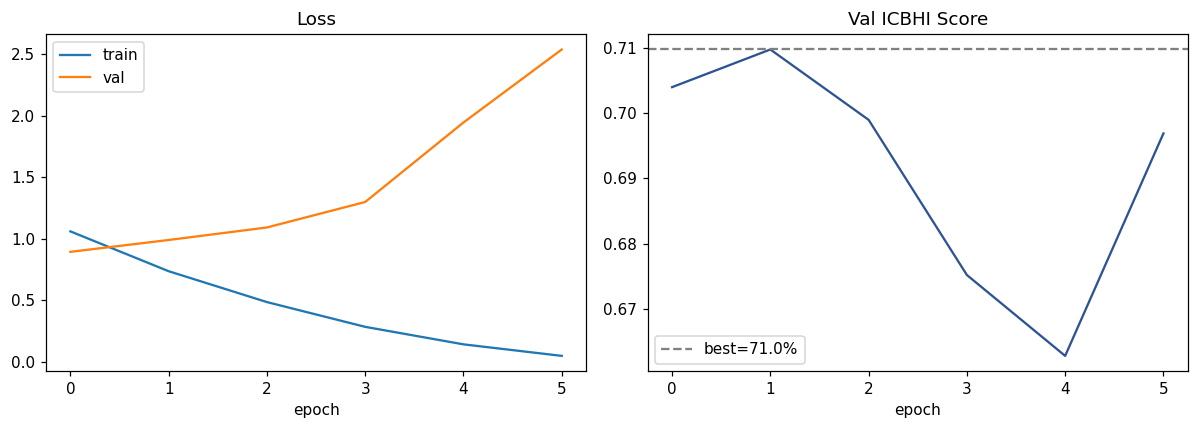

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["val_icbhi_score"], color="#2E5395")
axes[1].axhline(best_val_score, linestyle="--", color="gray", label=f"best={best_val_score*100:.1f}%")
axes[1].set_title("Val ICBHI Score")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## **11. Evaluate the Selected Checkpoint**

Reload the checkpoint selected using the validation ICBHI score. Evaluate it on the validation split to report the selected model's validation performance, then evaluate it on the held-out test split.

The test results provide the final evaluation for this experiment and should not be used to select the checkpoint or tune hyperparameters.


--- AST + Cross-Entropy (val, best checkpoint) ---
Sensitivity: 67.45%
Specificity: 74.51%
ICBHI Score:  70.98%

              precision    recall  f1-score   support

      normal       0.76      0.75      0.75       663
     crackle       0.56      0.50      0.53       347
      wheeze       0.34      0.70      0.46        66
        both       0.21      0.14      0.17        57

    accuracy                           0.64      1133
   macro avg       0.47      0.52      0.48      1133
weighted avg       0.65      0.64      0.64      1133



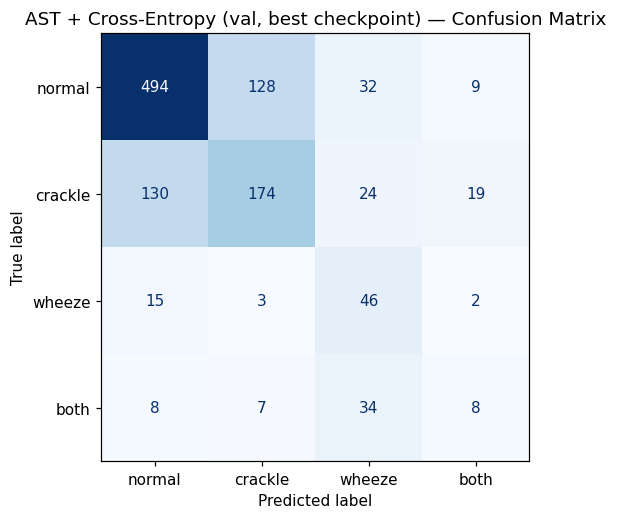

In [13]:
model.load_state_dict(torch.load(best_checkpoint_path))
model.eval()

def predict_all(loader):
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)
    return all_true, all_pred


val_true, val_pred = predict_all(val_loader)
ast_val_scores = evaluate_and_report(val_true, val_pred, "AST + Cross-Entropy (val, best checkpoint)")
log_result("AST + Cross-Entropy", "val", ast_val_scores, notes="best epoch by val ICBHI Score")

--- AST + Cross-Entropy (TEST) ---
Sensitivity: 56.51%
Specificity: 76.87%
ICBHI Score:  66.69%

              precision    recall  f1-score   support

      normal       0.72      0.77      0.75       709
     crackle       0.56      0.21      0.30       298
      wheeze       0.20      0.38      0.26       104
        both       0.21      0.36      0.27        74

    accuracy                           0.57      1185
   macro avg       0.42      0.43      0.39      1185
weighted avg       0.61      0.57      0.56      1185



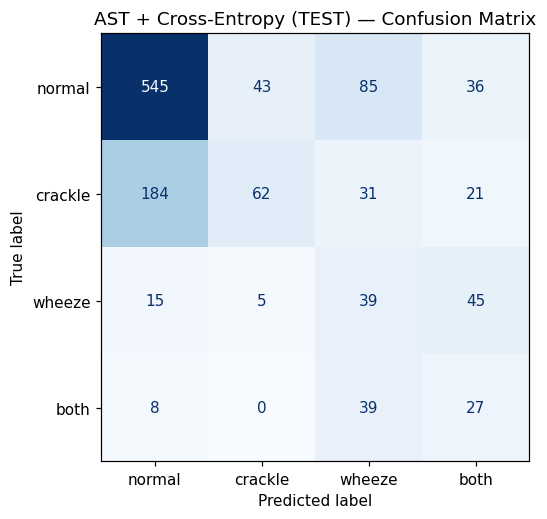

In [14]:
# --- TEST set  ---
test_true, test_pred = predict_all(test_loader)
ast_test_scores = evaluate_and_report(test_true, test_pred, "AST + Cross-Entropy (TEST)")
log_result("AST + Cross-Entropy", "test", ast_test_scores)

## **12. Results Summary — Validation and Test**

In [15]:
results_df = pd.DataFrame(results_log)
results_df["sensitivity"] = (results_df["sensitivity"] * 100).round(2)
results_df["specificity"] = (results_df["specificity"] * 100).round(2)
results_df["icbhi_score"] = (results_df["icbhi_score"] * 100).round(2)

display_cols = ["model", "split", "sensitivity", "specificity", "icbhi_score", "notes"]
results_df[display_cols].to_csv(RESULTS_CSV, index=False)
results_df[display_cols]

,model,split,sensitivity,specificity,icbhi_score,notes
0,AST + Cross-Entropy,val,67.45,74.51,70.98,best epoch by val ICBHI Score
1,AST + Cross-Entropy,test,56.51,76.87,66.69,


## 12. Phase 3A Summary — AST with Cross-Entropy

This experiment fine-tunes the pretrained Audio Spectrogram Transformer for four-class respiratory sound classification using class-weighted cross-entropy.

### Methodology

* Reused the project’s patient-level train, validation and test manifests.
* Extracted annotated respiratory cycles from the raw audio.
* Applied bandpass filtering, resampling to 16 kHz and fixed-length waveform handling.
* Reused cached waveforms and the pretrained AST feature extractor.
* Fine-tuned the four-class AST classifier using weighted cross-entropy.
* Selected the checkpoint using validation ICBHI score and early stopping.

### Recorded results

* **Validation ICBHI score:** 70.98%
* **Test ICBHI score:** 66.69%

### Outputs

* Best validation-selected AST checkpoint.
* Training and validation curves.
* Validation and test classification reports and confusion matrices.
* Results CSV containing the recorded metrics.

### Limitations

These results use the project’s internal patient-level 70/15/15 split. Direct comparison with published studies requires a compatible evaluation protocol. The experiment evaluates respiratory-sound classification and does not establish clinical diagnostic performance.

### Connection to subsequent experiments

This experiment serves as the cross-entropy reference for the subsequent focal-loss, supervised-contrastive-learning and augmentation studies. Their results should be compared using clearly documented splits, preprocessing and evaluation metrics.
